<a href="https://colab.research.google.com/github/aarushisubedi01/K-Means-Clustering/blob/main/Machine_Learning_K_means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-Means Implementation using the Iris DataSet**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans # this is used for clustering
from sklearn.preprocessing import StandardScaler # optional

In [ ]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

In [ ]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
X = X[['sepal length (cm)', 'petal length (cm)']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-0.90068117, -1.34022653],
       [-1.14301691, -1.34022653],
       [-1.38535265, -1.39706395],
       [-1.50652052, -1.2833891 ],
       [-1.02184904, -1.34022653],
       [-0.53717756, -1.16971425],
       [-1.50652052, -1.34022653],
       [-1.02184904, -1.2833891 ],
       [-1.74885626, -1.34022653],
       [-1.14301691, -1.2833891 ],
       [-0.53717756, -1.2833891 ],
       [-1.26418478, -1.22655167],
       [-1.26418478, -1.34022653],
       [-1.87002413, -1.51073881],
       [-0.05250608, -1.45390138],
       [-0.17367395, -1.2833891 ],
       [-0.53717756, -1.39706395],
       [-0.90068117, -1.34022653],
       [-0.17367395, -1.16971425],
       [-0.90068117, -1.2833891 ],
       [-0.53717756, -1.16971425],
       [-0.90068117, -1.2833891 ],
       [-1.50652052, -1.56757623],
       [-0.90068117, -1.16971425],
       [-1.26418478, -1.05603939],
       [-1.02184904, -1.22655167],
       [-1.02184904, -1.22655167],
       [-0.7795133 , -1.2833891 ],
       [-0.7795133 ,

In [ ]:
# Now, applying K-Means

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_

In [ ]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 0, 2, 2, 1, 0, 2, 1, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 2], dtype=int32)

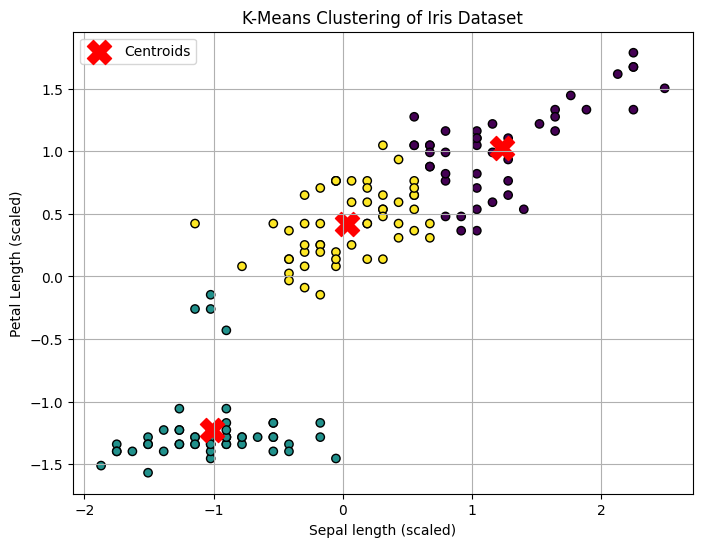

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=labels, # this is my cluster labels
            cmap='viridis',
            edgecolor ='k'
)

# now plotling the cluster centers in red with X axis

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, # Size of centroid markers
            c='red',
            marker='X',
            label='Centroids'
            )
plt.title('K-Means Clustering of Iris Dataset')
plt.xlabel('Sepal length (scaled)')
plt.ylabel('Petal Length (scaled)')

plt.legend()
plt.grid(True)
plt.show()

# **Elbow Method**

In [ ]:
# WCSS - Within- Cluster Sum of Squares

# It means how close the data points in each cluster are to their own cluster center.

# Lower WCSS = better clustering (less distance)

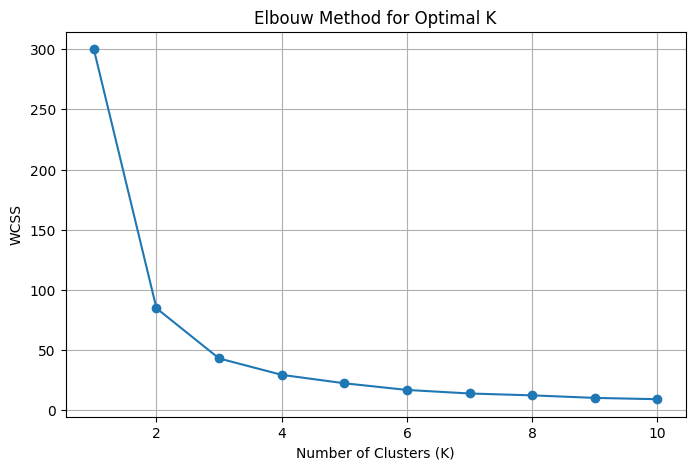

In [ ]:
wcss = []
for i in range(1,11): # Trying K from 1 to 10
  km = KMeans(n_clusters=i, random_state=42) # Creating k-means model with i clusters
  km.fit(X_scaled) # now fitting the model on our data
  wcss.append(km.inertia_) # save the WCSS (inertia_) for this K

# this is the total WCSS for that K
# As k value increases, WCSS usually gets smallar (clusters are tighter)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbouw Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()